In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from kmodes.kprototypes import KPrototypes
import gower
import seaborn as sns

In [ ]:
df_original = pd.read_csv('data/dataset.csv')
df_original = df_original.dropna()
df = df_original.copy()
#(344, 6)

In [15]:
df = df.drop(columns=['species'])  # Remove a coluna de rótulo para clustering

In [16]:
var_list = ['island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

In [19]:
df.head()

,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [ ]:
#Pré-processamento antes de passar pelo algoritmo de clustering

col_num = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
col_cat = ['island', 'sex']

scaler = StandardScaler()
df[col_num] = scaler.fit_transform(df[col_num])

posicoes_categoricas = [df.columns.get_loc(col) for col in col_cat]
matriz_dados = df.to_numpy()

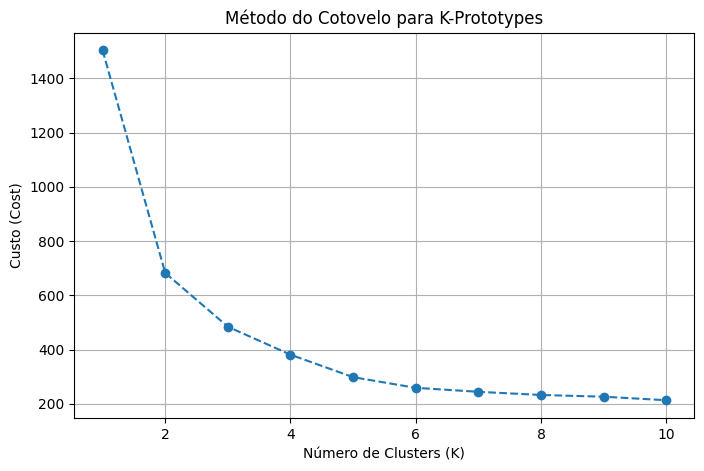

In [ ]:
#Identificação do k ideal usando o método do cotovelo

custos = []
K_maximo = 10

for k in range(1, K_maximo + 1):
    # init='Cao' é um método eficiente de inicialização para dados categóricos
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=3, random_state=42, n_jobs=-1)
    kproto.fit(matriz_dados, categorical=posicoes_categoricas)
    custos.append(kproto.cost_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, K_maximo + 1), custos, marker='o', linestyle='--')
plt.title('Método do Cotovelo para K-Prototypes')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Custo (Cost)')
plt.grid(True)
plt.show()

In [40]:
j = 0
for i in custos:
    j += 1
    print(f"K={j}, Erro Quadrático Médio = {i}")

K=1, Erro Quadrático Médio = 1503.9999999999995
K=2, Erro Quadrático Médio = 682.6093544891725
K=3, Erro Quadrático Médio = 484.16724809518524
K=4, Erro Quadrático Médio = 381.11252332924846
K=5, Erro Quadrático Médio = 298.07502910833443
K=6, Erro Quadrático Médio = 258.82570390875134
K=7, Erro Quadrático Médio = 244.11249417080728
K=8, Erro Quadrático Médio = 232.4229226084518
K=9, Erro Quadrático Médio = 226.02590855439135
K=10, Erro Quadrático Médio = 213.06238911107855


In [24]:
k_ideal = 3
kproto_final = KPrototypes(n_clusters=k_ideal, init='Cao', n_init=5, random_state=42, n_jobs=-1)
clusters_preditos = kproto_final.fit_predict(matriz_dados, categorical=posicoes_categoricas)

# Avaliação do modelo

Como Interpretar a Imagem Gerada:
A Diagonal Principal: Você verá quadrados vibrantes/claros descendo pela diagonal. Eles representam a similaridade dos itens do mesmo cluster. Quanto mais brilhante e homogêneo for o quadrado, mais coeso é aquele grupo.

Fora da Diagonal: O espaço fora desses quadrados centrais representa a similaridade entre itens de clusters diferentes (o equivalente visual do BSS). O ideal é que essas áreas sejam as mais escuras possíveis, indicando que clusters distintos não se misturam.

Ruído: Se você vir listras claras cruzando a área de outros clusters, significa que há pontos na fronteira de decisão ou que o agrupamento está confundindo certos perfis.

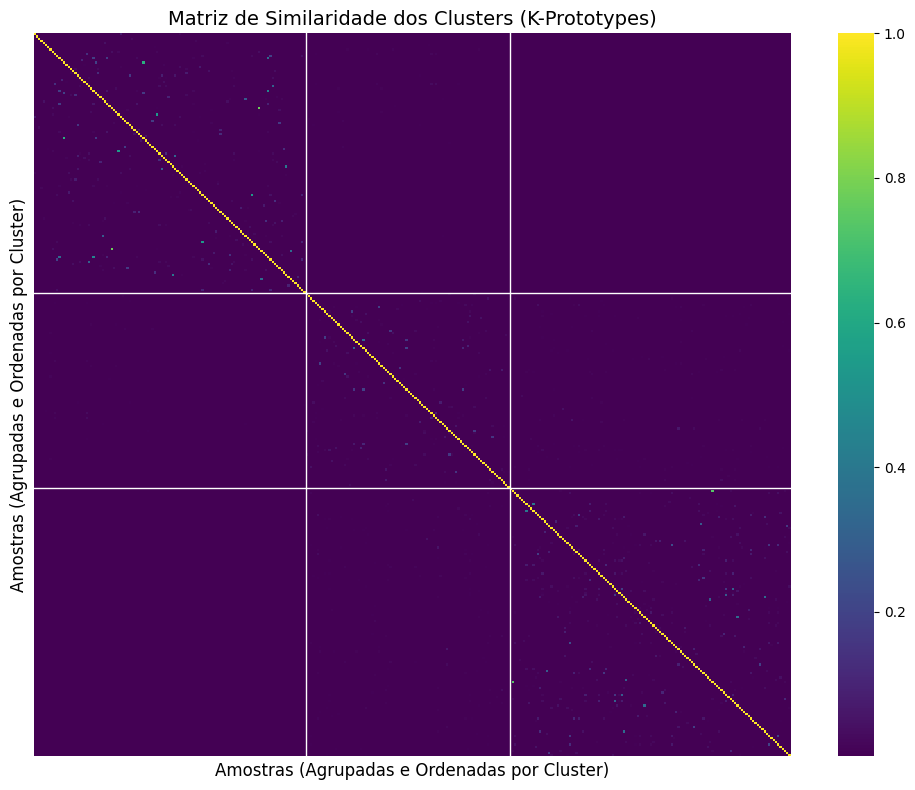

In [54]:
df_vis = df_original.copy()

#df_vis = df_vis.groupby('Cluster').sample(n=300, random_state=42)
df_vis = df_vis.sort_values(by='Cluster')
num_data = df_vis[col_num].values.astype(float)
cat_data = df_vis[col_cat].values

gamma = kproto_final.gamma

# ==========================================
# 2. Cálculo da Matriz de Distância (Estilo K-Prototypes)
# ==========================================
# Usamos "broadcasting" do NumPy para calcular (N, 1, F) - (1, N, F) -> (N, N, F)
# Isso é muito mais rápido que usar loops 'for'

# Distância Numérica: (x - y)^2
num_dist = np.sum((num_data[:, np.newaxis, :] - num_data[np.newaxis, :, :]) ** 2, axis=2)

# Distância Categórica: conta quantos atributos são diferentes
cat_dist = np.sum(cat_data[:, np.newaxis, :] != cat_data[np.newaxis, :, :], axis=2)

# Distância Total combinada com o gamma
dist_matrix = num_dist + (gamma * cat_dist)

# ==========================================
# 3. Conversão para Similaridade
# ==========================================
# Invertemos a distância: Distância 0 = Similaridade 1. Distância infinita = Similaridade 0.
sim_matrix = 1 / (1 + dist_matrix)

# ==========================================
# 4. Plotagem do Heatmap
# ==========================================
plt.figure(figsize=(10, 8))

# Utilizamos cmap='viridis' (ou 'magma'). Cores claras representam alta similaridade.
sns.heatmap(sim_matrix, 
            cmap='viridis', 
            xticklabels=False, 
            yticklabels=False)

# Adicionando linhas para delimitar visualmente onde um cluster começa e termina
cluster_counts = df_vis['Cluster'].value_counts(sort=False).sort_index()
cumulative_counts = np.cumsum(cluster_counts.values)

for count in cumulative_counts[:-1]:
    plt.axhline(count, color='white', linewidth=1)
    plt.axvline(count, color='white', linewidth=1)

plt.title('Matriz de Similaridade dos Clusters (K-Prototypes)', fontsize=14)
plt.xlabel('Amostras (Agrupadas e Ordenadas por Cluster)', fontsize=12)
plt.ylabel('Amostras (Agrupadas e Ordenadas por Cluster)', fontsize=12)
plt.tight_layout()
plt.show()

# Eda simples dos grupos

In [27]:
df_original['Cluster'] = clusters_preditos

In [29]:
print(df_original['Cluster'].value_counts().sort_index())
print(df_original['species'].value_counts().sort_index())

Cluster
0    120
1     90
2    124
Name: count, dtype: int64
species
Adelie       146
Chinstrap     68
Gentoo       120
Name: count, dtype: int64


In [31]:
perfil_numerico = df_original.groupby('Cluster')[col_num].mean()
print(perfil_numerico)

         culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
Cluster                                                                   
0               47.542500        15.002500         217.233333  5090.625000
1               47.075556        18.862222         197.266667  3944.722222
2               38.324194        18.013710         188.040323  3547.782258


In [33]:
perfil_categorico = df_original.groupby('Cluster')[col_cat].agg(lambda x: x.mode().iloc[0])
print(perfil_categorico)

         island     sex
Cluster                
0        Biscoe    MALE
1         Dream    MALE
2         Dream  FEMALE
